# 🔍 Exploratory Data Analysis (EDA)

This notebook serves as the foundational phase of our causal analysis of employment programme effects (CVE vs. OPP).

### Structure
| Block | Content | DAG arrow justified |
|---|---|---|
| **Housekeeping** | Load, clean, define groups | — |
| **Part 1** | Observable selection: t-tests, SMD, Love Plot, omnibus F-test | `X → D` |
| **Part 2** | Instrument validity & non-compliance | `Z → D`, `Z ✗→ Y` |
| **Part 3** | Risk-based allocation — parking hypothesis | `rsqstat → D` |
| **Part 4** | Unobservable confounding: raw vs. adjusted gap | `U → D`, `U → Y` |
| **Part 5** | Outcome distributions | `D → Y` |
| **DAG** | Causal graph formalising all assumptions | — |

---
## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import ttest_ind

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

COLORS = {
    "CVE":        "#1D9E75",
    "OPP":        "#7F77DD",
    "non_traite": "#888780",
    "gap":        "#D85A30",
}

VAR_LABELS = {
    "age":                 "Age",
    "femme":               "Female",
    "marie":               "Married",
    "nenf":                "Nb. of children",
    "etranger":            "Foreign-born",
    "duree_listes_horsAR": "Prior unemp. duration (days)",
    "nivetude1":           "Education: level 1",
    "nivetude2":           "Education: level 2",
    "nivetude3":           "Education: level 3",
    "nivetude4":           "Education: level 4",
}

In [2]:
# Load the dataset
file_path = "/Users/salmaelaazdoudi/Downloads/113904-V1/Archive/dataPrivatePublic.dta"
df = pd.read_stata(file_path)
print(f"Dataset loaded with {df.shape[0]:,} observations and {df.shape[1]} variables.")

Dataset loaded with 43,977 observations and 83 variables.


---
## Housekeeping

In [3]:
# Check dimensions and structure
print(f"Shape: {df.shape}")
df.info()

Shape: (43977, 83)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43977 entries, 0 to 43976
Data columns (total 83 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   ale                    43977 non-null  object  
 1   mois_saisie_occ        43977 non-null  float32 
 2   acceptationCVE         43977 non-null  float64 
 3   acceptationOPP         43977 non-null  float32 
 4   nregion                43977 non-null  object  
 5   ndem                   43977 non-null  int8    
 6   sexe                   43977 non-null  object  
 7   nenf                   43977 non-null  int8    
 8   nation                 43977 non-null  object  
 9   motins                 43977 non-null  object  
 10  temps                  43977 non-null  object  
 11  exper                  43977 non-null  object  
 12  age                    43977 non-null  int16   
 13  rsqstat                43977 non-null  object  
 14  cemploi            

In [4]:
df.head()

,ale,mois_saisie_occ,acceptationCVE,acceptationOPP,nregion,ndem,sexe,nenf,nation,motins,...,acceptationCVE_9MOIS,POIDS_PZ_9MOIS,EMPLOI_12MOIS,AUTRE_12MOIS,RADIE_12MOIS,EMPLOI_AR110_12MOIS,SUCCES_OPP_12MOIS,acceptationOPP_12MOIS,acceptationCVE_12MOIS,POIDS_PZ_12MOIS
0,91043,11.0,0.0,0.0,116,2,1,3,01,G,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1,91008,12.0,0.0,1.0,116,3,1,0,22,8,...,0.0,0.969888,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.969888
2,91146,5.0,0.0,0.0,116,1,1,2,01,2,...,0.0,0.964660,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.964660
3,91008,6.0,0.0,1.0,116,3,2,2,01,8,...,0.0,0.964660,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.964660
4,91146,3.0,0.0,0.0,116,1,1,1,01,2,...,0.0,1.116305,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.116305


In [5]:
# Check monotonicity of cumulative acceptance variables
print("Violations 6M > 9M:",  (df["acceptationCVE_6MOIS"] > df["acceptationCVE_9MOIS"]).sum())
print("Violations 9M > 12M:", (df["acceptationCVE_9MOIS"] > df["acceptationCVE_12MOIS"]).sum())

Violations 6M > 9M: 0
Violations 9M > 12M: 0


Acceptance at 6 months ⊂ acceptance at 9 months ⊂ acceptance at 12 months — they are cumulative indicators of the same event.

In [6]:
core_vars = [
    # IV + treatment
    "Z", "acceptationCVE", "acceptationOPP",
    # Outcomes
    "EMPLOI_3MOIS", "EMPLOI_6MOIS", "EMPLOI_9MOIS", "EMPLOI_12MOIS",
    # Controls
    "age", "femme", "marie", "nenf", "etranger", "zus",
    "duree_listes_horsAR",
    "nivetude1", "nivetude2", "nivetude3", "nivetude4",
    "salaire", "exper", "nregion", "CS", "rsqstat"
]

df_eda = df[core_vars].copy()

num_cols = [
    "Z", "acceptationCVE", "acceptationOPP",
    "EMPLOI_3MOIS", "EMPLOI_6MOIS", "EMPLOI_9MOIS", "EMPLOI_12MOIS",
    "age", "femme", "marie", "nenf", "etranger",
    "duree_listes_horsAR",
    "nivetude1", "nivetude2", "nivetude3", "nivetude4"
]
df_eda[num_cols] = df_eda[num_cols].apply(pd.to_numeric, errors="coerce")

# Define treatment groups
df_eda["group"] = np.select(
    [df_eda["acceptationCVE"] == 1, df_eda["acceptationOPP"] == 1],
    ["CVE", "OPP"],
    default="non_traite"
)

X_cols = [
    "age", "femme", "marie", "nenf", "etranger",
    "duree_listes_horsAR",
    "nivetude1", "nivetude2", "nivetude3", "nivetude4"
]

print("Group counts:")
print(df_eda["group"].value_counts())
print(f"\nAnalytical sample: {len(df_eda):,} observations")

Group counts:
group
non_traite    26620
OPP           15687
CVE            1670
Name: count, dtype: int64

Analytical sample: 43,977 observations


---
## Part 1 — Observable Selection: X → D

Treatment (actual programme take-up) was **not** randomised — only assignment was. Here we test whether participants who accepted CVE or OPP differ systematically from non-treated individuals on baseline observables.

This section establishes the **X → D** arrow in the DAG: observable characteristics predict treatment take-up, meaning naïve comparisons of outcomes would be confounded.

We use three complementary approaches:
1. **t-tests** — variable-by-variable mean differences  
2. **Standardised Mean Differences (SMD)** — scale-free imbalance with Love Plot  
3. **Omnibus F-test** — joint test of all covariates simultaneously

### 1.1 — t-tests on mean differences

In [7]:
results = []
for var in X_cols:
    x_cve = df_eda.loc[df_eda["group"] == "CVE", var].dropna()
    x_opp = df_eda.loc[df_eda["group"] == "OPP", var].dropna()
    x_nt  = df_eda.loc[df_eda["group"] == "non_traite", var].dropna()
    t_cve, p_cve = ttest_ind(x_cve, x_nt, equal_var=False)
    t_opp, p_opp = ttest_ind(x_opp, x_nt, equal_var=False)
    results.append({
        "Variable":          VAR_LABELS[var],
        "Mean CVE":          x_cve.mean(),
        "Mean OPP":          x_opp.mean(),
        "Mean non-treated":  x_nt.mean(),
        "Diff CVE":          x_cve.mean() - x_nt.mean(),
        "p CVE":             p_cve,
        "Diff OPP":          x_opp.mean() - x_nt.mean(),
        "p OPP":             p_opp,
    })

balance_test = pd.DataFrame(results)

def fmt_p(p):
    if p < 0.001: return "<0.001 ***"
    if p < 0.01:  return f"{p:.3f} **"
    if p < 0.05:  return f"{p:.3f} *"
    return f"{p:.3f}"

display_df = balance_test.copy()
display_df["p CVE"] = balance_test["p CVE"].apply(fmt_p)
display_df["p OPP"] = balance_test["p OPP"].apply(fmt_p)

display(
    display_df.style
    .format({"Mean CVE": "{:.3f}", "Mean OPP": "{:.3f}", "Mean non-treated": "{:.3f}",
             "Diff CVE": "{:+.3f}", "Diff OPP": "{:+.3f}"})
    .set_caption("Table 1 — Mean differences: treated vs. non-treated (Welch t-test)")
    .set_table_styles([{"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "13px")]}])
    .hide(axis="index")
)

Variable,Mean CVE,Mean OPP,Mean non-treated,Diff CVE,p CVE,Diff OPP,p OPP
Age,37.180,37.164,36.421,+0.758,0.003 **,+0.743,<0.001 ***
Female,0.499,0.505,0.499,+0.001,0.950,+0.006,0.213
Married,0.468,0.477,0.453,+0.015,0.238,+0.025,<0.001 ***
Nb. of children,0.905,0.931,0.885,+0.020,0.522,+0.045,<0.001 ***
Foreign-born,0.837,0.830,0.802,+0.034,<0.001 ***,+0.028,<0.001 ***
Prior unemp. duration (days),237.973,236.822,215.616,+22.357,<0.001 ***,+21.207,<0.001 ***
Education: level 1,0.307,0.320,0.317,-0.009,0.421,+0.004,0.423
Education: level 2,0.201,0.196,0.195,+0.006,0.585,+0.001,0.813
Education: level 3,0.319,0.305,0.292,+0.026,0.025 *,+0.013,0.006 **
Education: level 4,0.174,0.179,0.196,-0.022,0.020 *,-0.017,<0.001 ***


Participants in both CVE and OPP show a substantially longer prior unemployment duration (`duree_listes_horsAR`) compared to non-treated individuals (~+22 days), suggesting treated individuals are more disadvantaged ex-ante. Treated individuals are also more likely to be foreign-born and slightly older. Gender (`femme`) appears well-balanced across groups.

### 1.2 — Standardised Mean Differences (SMD) & Love Plot

In [8]:
def smd(x1, x2):
    m1, m2 = x1.mean(), x2.mean()
    v1, v2 = x1.var(ddof=1), x2.var(ddof=1)
    pooled_sd = np.sqrt((v1 + v2) / 2)
    return 0.0 if pooled_sd == 0 else (m1 - m2) / pooled_sd

smd_results = []
for var in X_cols:
    x_cve = df_eda.loc[df_eda["group"] == "CVE", var].dropna()
    x_opp = df_eda.loc[df_eda["group"] == "OPP", var].dropna()
    x_nt  = df_eda.loc[df_eda["group"] == "non_traite", var].dropna()
    smd_results.append({
        "variable":              var,
        "label":                 VAR_LABELS[var],
        "SMD_CVE_vs_non_traite": smd(x_cve, x_nt),
        "SMD_OPP_vs_non_traite": smd(x_opp, x_nt),
        "SMD_CVE_vs_OPP":        smd(x_cve, x_opp),
    })

smd_table = pd.DataFrame(smd_results).sort_values(
    "SMD_CVE_vs_non_traite", key=lambda s: abs(s), ascending=False
)

display(
    smd_table[["label", "SMD_CVE_vs_non_traite", "SMD_OPP_vs_non_traite", "SMD_CVE_vs_OPP"]]
    .rename(columns={
        "label": "Variable",
        "SMD_CVE_vs_non_traite": "CVE vs. non-treated",
        "SMD_OPP_vs_non_traite": "OPP vs. non-treated",
        "SMD_CVE_vs_OPP":        "CVE vs. OPP"
    })
    .style
    .format("{:+.3f}", subset=["CVE vs. non-treated", "OPP vs. non-treated", "CVE vs. OPP"])
    .background_gradient(cmap="RdYlGn_r", vmin=-0.25, vmax=0.25,
                         subset=["CVE vs. non-treated", "OPP vs. non-treated"])
    .set_caption("Table 2 — Standardised Mean Differences (|SMD| > 0.1 = notable, > 0.2 = large)")
    .set_table_styles([{"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "13px")]}])
    .hide(axis="index")
)

Variable,CVE vs. non-treated,OPP vs. non-treated,CVE vs. OPP
Prior unemp. duration (days),+0.188,+0.178,+0.010
Foreign-born,+0.089,+0.072,+0.018
Age,+0.073,+0.071,+0.002
Education: level 4,-0.057,-0.044,-0.014
Education: level 3,+0.057,+0.027,+0.030
Married,+0.030,+0.049,-0.019
Education: level 1,-0.020,+0.008,-0.028
Nb. of children,+0.016,+0.036,-0.020
Education: level 2,+0.014,+0.002,+0.011
Female,+0.002,+0.013,-0.011


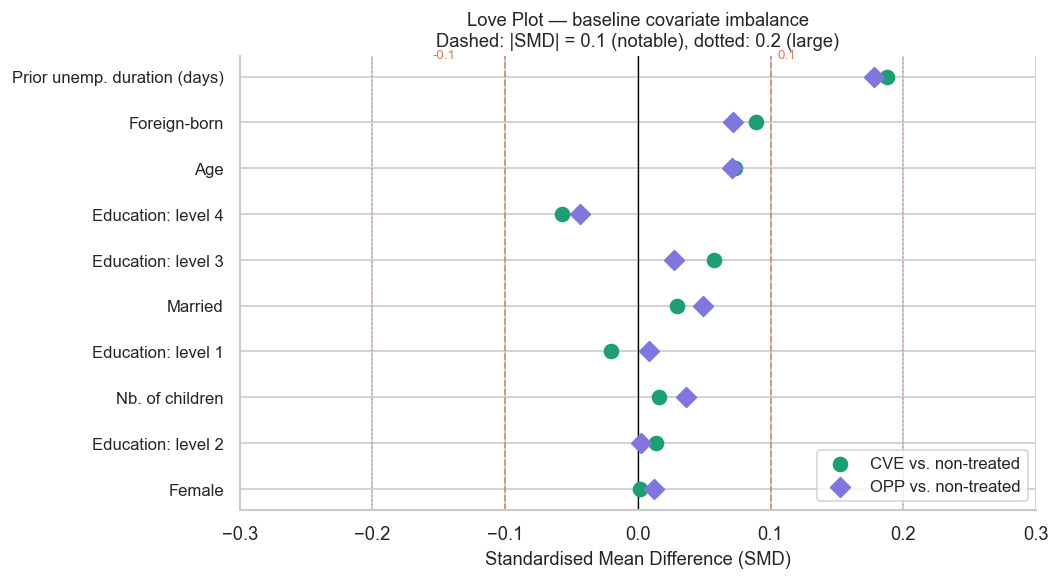

In [9]:
# ── Love Plot ─────────────────────────────────────────────────────
smd_plot = smd_table.sort_values("SMD_CVE_vs_non_traite", key=abs, ascending=True)
y_pos = np.arange(len(smd_plot))

fig, ax = plt.subplots(figsize=(9, 5))

for i, (_, row) in enumerate(smd_plot.iterrows()):
    ax.plot([row["SMD_CVE_vs_non_traite"], row["SMD_OPP_vs_non_traite"]],
            [i, i], color="#D3D1C7", linewidth=1.2, zorder=1)

ax.scatter(smd_plot["SMD_CVE_vs_non_traite"], y_pos,
           color=COLORS["CVE"], s=70, zorder=3, label="CVE vs. non-treated")
ax.scatter(smd_plot["SMD_OPP_vs_non_traite"], y_pos,
           color=COLORS["OPP"], s=70, marker="D", zorder=3, label="OPP vs. non-treated")

ax.axvline(0,    color="black",          linewidth=0.8)
ax.axvline(0.1,  color=COLORS["gap"],    linewidth=1, linestyle="--", alpha=0.6)
ax.axvline(-0.1, color=COLORS["gap"],    linewidth=1, linestyle="--", alpha=0.6)
ax.axvline(0.2,  color=COLORS["gap"],    linewidth=1, linestyle=":",  alpha=0.4)
ax.axvline(-0.2, color=COLORS["gap"],    linewidth=1, linestyle=":",  alpha=0.4)
ax.text(0.105,  len(smd_plot) - 0.6, "0.1",  fontsize=8, color=COLORS["gap"], alpha=0.8)
ax.text(-0.155, len(smd_plot) - 0.6, "-0.1", fontsize=8, color=COLORS["gap"], alpha=0.8)

ax.set_yticks(y_pos)
ax.set_yticklabels(smd_plot["label"], fontsize=10)
ax.set_xlabel("Standardised Mean Difference (SMD)", fontsize=11)
ax.set_title("Love Plot — baseline covariate imbalance\nDashed: |SMD| = 0.1 (notable), dotted: 0.2 (large)", fontsize=11)
ax.legend(fontsize=10, loc="lower right")
ax.set_xlim(-0.30, 0.30)
plt.tight_layout()
plt.show()

The largest imbalance concerns prior unemployment duration (`duree_listes_horsAR`), with SMD ≈ 0.18 — close to the conventional 0.2 threshold. Migration status (`etranger`) and age show SMD < 0.1. Gender (`femme`) is near-perfectly balanced.

### 1.3 — Omnibus F-test: joint predictive power of X on take-up

In [10]:
df_eda[X_cols] = df_eda[X_cols].apply(pd.to_numeric, errors="coerce")

def omnibus_balance_test(df, dep_col, X_cols, subset_mask=None):
    d = df.copy()
    if subset_mask is not None:
        d = d.loc[subset_mask].copy()
    d = d[[dep_col] + X_cols].dropna()
    y = pd.to_numeric(d[dep_col], errors="coerce")
    X = sm.add_constant(d[X_cols])
    model = sm.OLS(y, X).fit()
    test  = model.f_test(np.eye(len(X_cols), len(X_cols) + 1, k=1))
    return model, test

mask_cve = df_eda["group"].isin(["CVE", "non_traite"])
df_eda.loc[mask_cve, "D_cve"] = (df_eda.loc[mask_cve, "group"] == "CVE").astype(int)
model_cve, test_cve = omnibus_balance_test(df_eda, "D_cve", X_cols, subset_mask=mask_cve)

mask_opp = df_eda["group"].isin(["OPP", "non_traite"])
df_eda.loc[mask_opp, "D_opp"] = (df_eda.loc[mask_opp, "group"] == "OPP").astype(int)
model_opp, test_opp = omnibus_balance_test(df_eda, "D_opp", X_cols, subset_mask=mask_opp)

omnibus_summary = pd.DataFrame({
    "Comparison":  ["CVE vs. non-treated", "OPP vs. non-treated"],
    "F-statistic": [float(test_cve.fvalue), float(test_opp.fvalue)],
    "p-value":     [float(test_cve.pvalue), float(test_opp.pvalue)],
    "R²":          [model_cve.rsquared,     model_opp.rsquared],
    "N":           [model_cve.nobs,         model_opp.nobs],
})

display(
    omnibus_summary.style
    .format({"F-statistic": "{:.2f}", "p-value": "{:.2e}", "R²": "{:.4f}", "N": "{:,.0f}"})
    .set_caption("Table 3 — Omnibus F-test: joint predictive power of X on treatment take-up")
    .set_table_styles([{"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "13px")]}])
    .hide(axis="index")
)

Comparison,F-statistic,p-value,R²,N
CVE vs. non-treated,8.07,3.86e-13,0.0028,"28,290"
OPP vs. non-treated,44.28,2.20e-88,0.0104,"42,307"


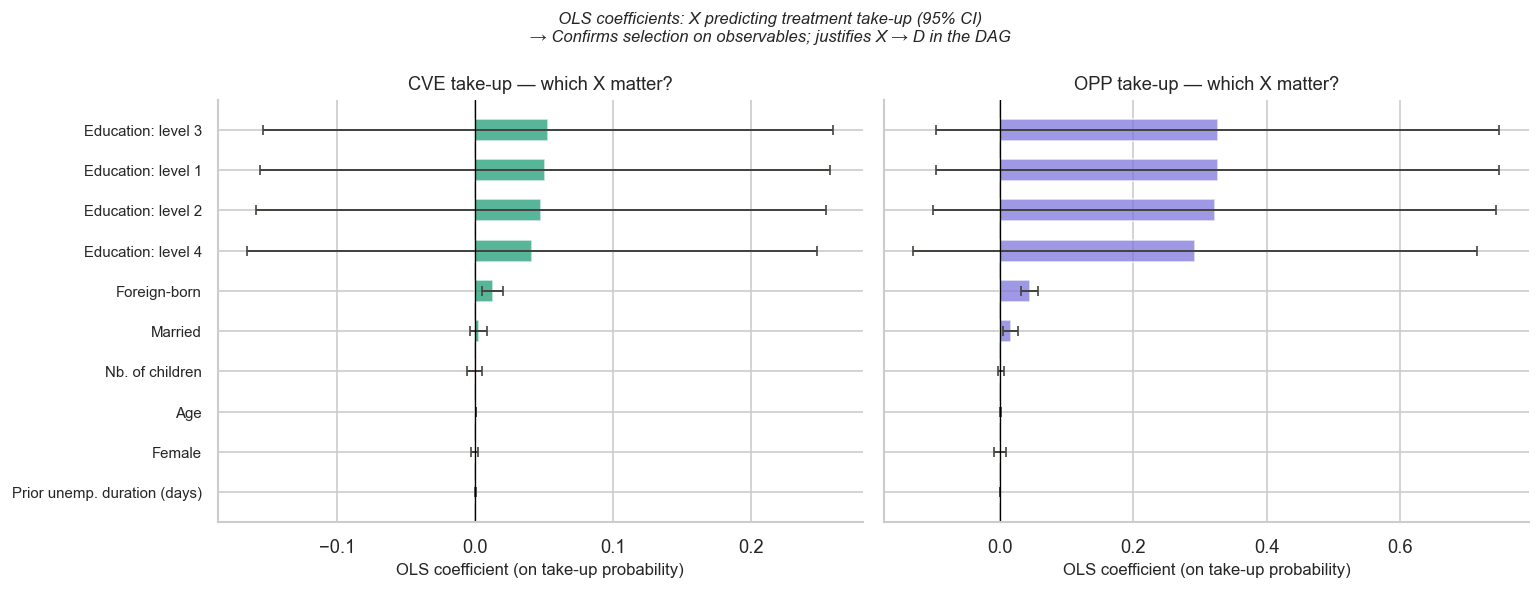

In [11]:
# ── Coefficient plot: which X predict take-up most strongly? ─────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, model, program, color in [
    (axes[0], model_cve, "CVE", COLORS["CVE"]),
    (axes[1], model_opp, "OPP", COLORS["OPP"]),
]:
    coef   = model.params[X_cols]
    ci     = model.conf_int().loc[X_cols]
    labels = [VAR_LABELS[v] for v in X_cols]
    order  = coef.abs().argsort()
    coef, ci = coef.iloc[order], ci.iloc[order]
    labels = [labels[i] for i in order]

    y_pos = np.arange(len(coef))
    ax.barh(y_pos, coef.values,
            xerr=[coef.values - ci.iloc[:, 0].values, ci.iloc[:, 1].values - coef.values],
            color=[color if v > 0 else COLORS["gap"] for v in coef.values],
            alpha=0.75, edgecolor="white", height=0.55,
            error_kw={"elinewidth": 1.2, "ecolor": "#444441", "capsize": 3})
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("OLS coefficient (on take-up probability)", fontsize=10)
    ax.set_title(f"{program} take-up — which X matter?", fontsize=11)

fig.suptitle("OLS coefficients: X predicting treatment take-up (95% CI)\n"
             "→ Confirms selection on observables; justifies X → D in the DAG",
             fontsize=10, style="italic")
plt.tight_layout()
plt.show()

**Takeaway — X → D confirmed.** The omnibus F-tests strongly reject the null. Selection is stronger for OPP than CVE (higher F-statistic, larger R²). Prior unemployment duration dominates all other predictors. Treatment participation is clearly non-random with respect to observable characteristics, justifying the **X → D** and **X → Y** arrows in the causal graph and the use of controls throughout.

---
## Part 2 — Instrument Validity: Z → D and Z ✗→ Y

The IV strategy requires that random assignment (Z) is **relevant** (it moves D) and satisfies the **exclusion restriction** (no direct path Z → Y). Here we document compliance rates and the extent of non-compliance and cross-over.

> **Justifies arrows:** `Z → D_CVE`, `Z → D_OPP`, and the *absence* of `Z → Y`.

In [12]:
# ── 2a. Compliance contingency tables ────────────────────────────
sample = df.loc[df["SAMPLE_CVEOPP"] == 1].copy()

for program, z_col, d_col in [
    ("CVE", "CVE", "acceptationCVE_6MOIS"),
    ("OPP", "OPP", "acceptationOPP_6MOIS"),
]:
    ct = pd.crosstab(
        sample[z_col].map({0: "Assigned Control", 1: f"Assigned {program}"}),
        sample[d_col].map({0: "Did not take up", 1: "Took up"}),
        margins=True, normalize="index",
    ).round(3) * 100
    print(f"\n── Compliance table: {program} (row % within assignment) ──")
    display(ct.style.format("{:.1f}%")
            .set_caption(f"Assignment × Take-up — {program} programme")
            .set_table_styles([{"selector": "caption",
                                 "props": [("font-weight", "bold"), ("font-size", "12px")]}]))


── Compliance table: CVE (row % within assignment) ──


acceptationCVE_6MOIS,Did not take up,Took up
CVE,,
Assigned CVE,69.2%,30.8%
Assigned Control,99.6%,0.4%
All,97.3%,2.7%



── Compliance table: OPP (row % within assignment) ──


acceptationOPP_6MOIS,Did not take up,Took up
OPP,,
Assigned Control,97.2%,2.8%
Assigned OPP,57.4%,42.6%
All,64.6%,35.4%


In [13]:
# ── 2b. Cross-over: assigned OPP but took CVE ────────────────────
ct_cross = pd.crosstab(
    sample["OPP"].map({0: "Assigned Control", 1: "Assigned OPP"}),
    sample["acceptationCVE_6MOIS"].map({0: "Did not take CVE", 1: "Took CVE"}),
    margins=True, normalize="index",
).round(3) * 100
print("── Cross-over: assigned OPP × took CVE ──")
display(ct_cross.style.format("{:.1f}%")
        .set_caption("Cross-over table")
        .set_table_styles([{"selector": "caption",
                             "props": [("font-weight", "bold"), ("font-size", "12px")]}]))

── Cross-over: assigned OPP × took CVE ──


acceptationCVE_6MOIS,Did not take CVE,Took CVE
OPP,,
Assigned Control,86.7%,13.3%
Assigned OPP,99.6%,0.4%
All,97.3%,2.7%


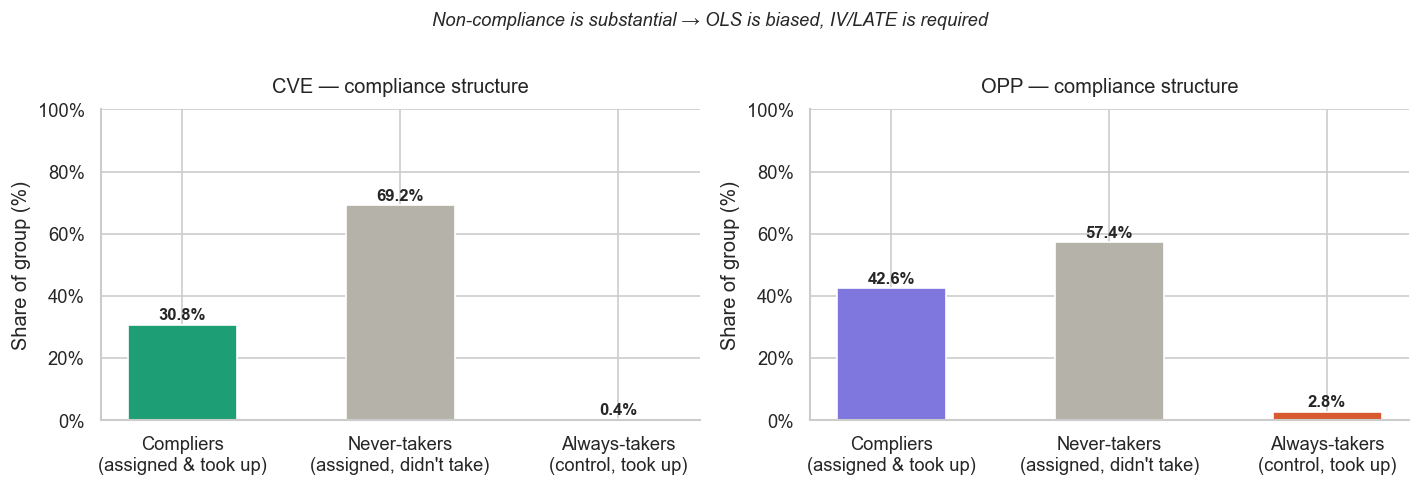

In [14]:
# ── 2c. Compliance structure bar chart ───────────────────────────
compliance_data = {
    "CVE": {
        "Compliers\n(assigned & took up)":      sample.loc[sample["CVE"]==1, "acceptationCVE_6MOIS"].mean(),
        "Never-takers\n(assigned, didn't take)": 1 - sample.loc[sample["CVE"]==1, "acceptationCVE_6MOIS"].mean(),
        "Always-takers\n(control, took up)":    sample.loc[sample["CVE"]==0, "acceptationCVE_6MOIS"].mean(),
    },
    "OPP": {
        "Compliers\n(assigned & took up)":      sample.loc[sample["OPP"]==1, "acceptationOPP_6MOIS"].mean(),
        "Never-takers\n(assigned, didn't take)": 1 - sample.loc[sample["OPP"]==1, "acceptationOPP_6MOIS"].mean(),
        "Always-takers\n(control, took up)":    sample.loc[sample["OPP"]==0, "acceptationOPP_6MOIS"].mean(),
    },
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, (prog, vals) in zip(axes, compliance_data.items()):
    bar_colors = [COLORS[prog], "#B4B2A9", COLORS["gap"]]
    bars = ax.bar(list(vals.keys()), [v * 100 for v in vals.values()],
                  color=bar_colors, width=0.5, edgecolor="white")
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{bar.get_height():.1f}%", ha="center", va="bottom",
                fontsize=10, fontweight="bold")
    ax.set_title(f"{prog} — compliance structure", fontsize=12, pad=10)
    ax.set_ylabel("Share of group (%)")
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())

fig.suptitle("Non-compliance is substantial → OLS is biased, IV/LATE is required",
             fontsize=11, style="italic", y=1.01)
plt.tight_layout()
plt.show()

**Takeaway — Z → D confirmed, Z ✗→ Y assumed.** Both programmes exhibit substantial non-compliance and cross-over, confirming that actual participation D is endogenous. The random assignment Z is a valid instrument: correlated with D (relevance) and assigned independently of individual unobservables (independence). The exclusion restriction — that Z affects Y only through D — is maintained by design: the lottery draw cannot affect employment prospects other than by determining programme access.

---
## Part 3 — Risk-Based Allocation: rsqstat → D (Parking Hypothesis)

If caseworkers or providers differentially allocate job seekers by ex-ante predicted risk, then rsqstat should predict programme take-up independently of assignment. This is the empirical test of the *parking* mechanism.

> **Justifies arrows:** `rsqstat → D_CVE`, `rsqstat → D_OPP`.

In [15]:
# ── 3a. Employment rates by risk group and programme ─────────────
df_h = df_eda[df_eda["group"].isin(["CVE", "OPP"])].copy()
df_h["rsqstat"] = df_h["rsqstat"].replace("", np.nan)
df_h = df_h.dropna(subset=["rsqstat", "EMPLOI_6MOIS"])

rates = df_h.groupby(["rsqstat", "group"])["EMPLOI_6MOIS"].mean().unstack()
rates["gap_OPP_minus_CVE"] = rates.get("OPP", pd.Series(dtype=float)) - rates.get("CVE", pd.Series(dtype=float))

display(
    rates.style
    .format("{:.1%}")
    .background_gradient(cmap="RdYlGn", subset=[c for c in rates.columns if c != "gap_OPP_minus_CVE"])
    .background_gradient(cmap="RdYlGn_r", subset=["gap_OPP_minus_CVE"])
    .set_caption("Table 4 — Employment rate at 6 months by risk group and programme")
    .set_table_styles([{"selector": "caption",
                         "props": [("font-weight", "bold"), ("font-size", "13px")]}])
)

group,CVE,OPP,gap_OPP_minus_CVE
rsqstat,,,
RS1,43.8%,29.6%,-14.1%
RS2,23.6%,20.5%,-3.0%
RS3,18.5%,13.8%,-4.7%


In [16]:
# ── 3b. Group composition by risk score ──────────────────────────
df_rs = df_eda.copy()
df_rs["rsqstat"] = df_rs["rsqstat"].replace("", np.nan)
df_rs = df_rs.dropna(subset=["rsqstat"])

comp = df_rs.groupby(["rsqstat", "group"]).size().unstack(fill_value=0)
comp_pct = comp.div(comp.sum(axis=1), axis=0) * 100

display(
    comp_pct.round(1).style
    .format("{:.1f}%")
    .background_gradient(cmap="YlOrRd", axis=1)
    .set_caption("Table 5 — Programme composition by risk group (row %)")
    .set_table_styles([{"selector": "caption",
                         "props": [("font-weight", "bold"), ("font-size", "13px")]}])
)

group,CVE,OPP,non_traite
rsqstat,,,
RS1,3.6%,34.4%,62.0%
RS2,3.9%,35.9%,60.1%
RS3,3.8%,41.3%,54.9%


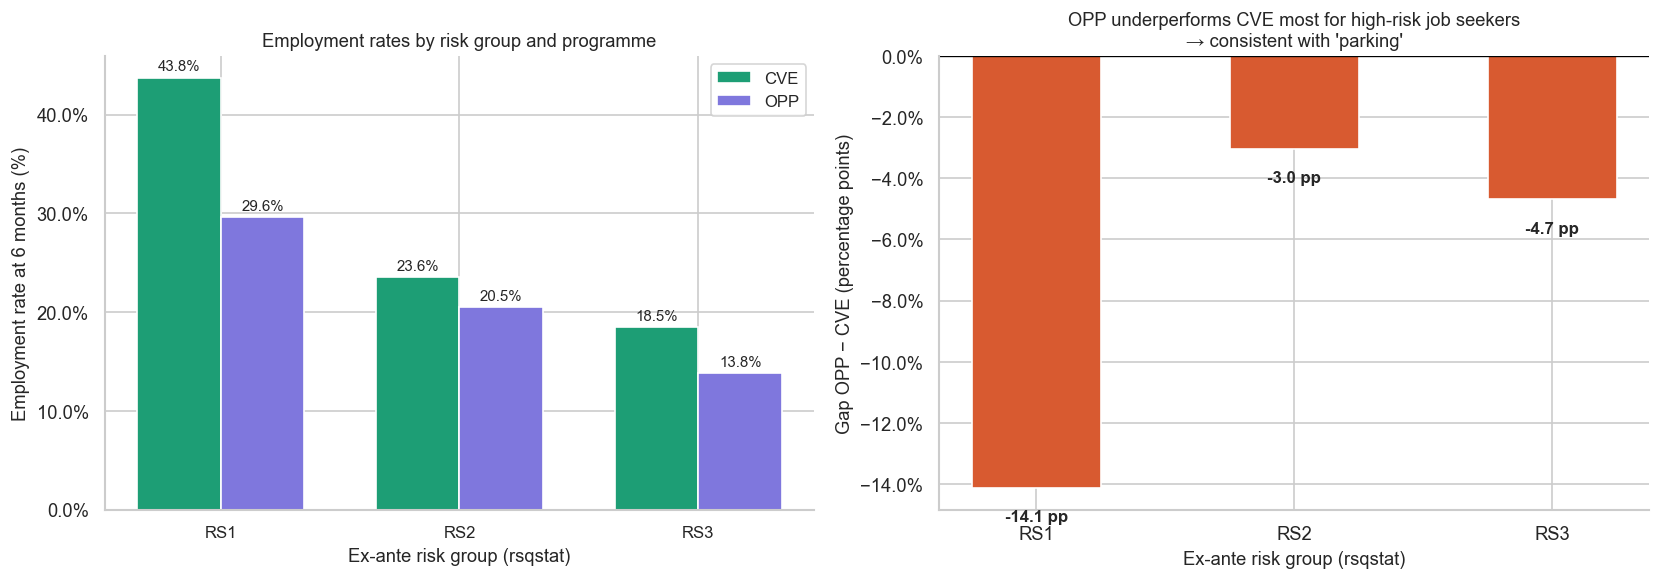

In [17]:
# ── 3c. Side-by-side bar chart: employment rate by risk group ─────
rsq_labels = rates.index.tolist()
cve_rates  = rates["CVE"].values  if "CVE"  in rates.columns else np.zeros(len(rsq_labels))
opp_rates  = rates["OPP"].values  if "OPP"  in rates.columns else np.zeros(len(rsq_labels))

x     = np.arange(len(rsq_labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: employment rates
ax = axes[0]
b1 = ax.bar(x - width/2, cve_rates * 100, width, label="CVE", color=COLORS["CVE"], edgecolor="white")
b2 = ax.bar(x + width/2, opp_rates * 100, width, label="OPP", color=COLORS["OPP"], edgecolor="white")
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(rsq_labels, fontsize=10)
ax.set_xlabel("Ex-ante risk group (rsqstat)", fontsize=11)
ax.set_ylabel("Employment rate at 6 months (%)", fontsize=11)
ax.set_title("Employment rates by risk group and programme", fontsize=11)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=10)

# Right: gap (OPP − CVE)
ax2 = axes[1]
gap_vals = (opp_rates - cve_rates) * 100
bar_colors = [COLORS["gap"] if g < 0 else COLORS["CVE"] for g in gap_vals]
bars = ax2.bar(rsq_labels, gap_vals, color=bar_colors, edgecolor="white", width=0.5)
for bar, val in zip(bars, gap_vals):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (0.3 if val >= 0 else -1.2),
             f"{val:+.1f} pp", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_xlabel("Ex-ante risk group (rsqstat)", fontsize=11)
ax2.set_ylabel("Gap OPP − CVE (percentage points)", fontsize=11)
ax2.set_title("OPP underperforms CVE most for high-risk job seekers\n→ consistent with 'parking'", fontsize=11)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.show()

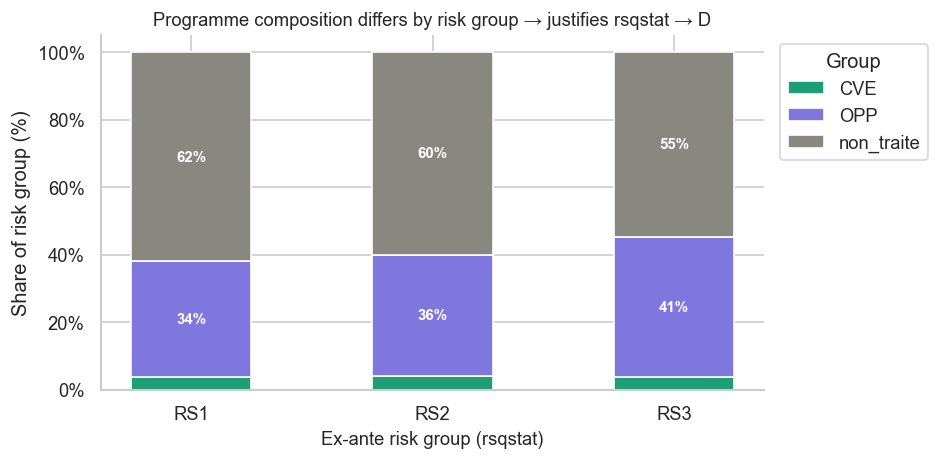

In [18]:
# ── 3d. Stacked bar: composition by risk group ────────────────────
groups_order = [g for g in ["CVE", "OPP", "non_traite"] if g in comp_pct.columns]
comp_ordered = comp_pct.reindex(columns=groups_order, fill_value=0)

fig, ax = plt.subplots(figsize=(8, 4))
bottom = np.zeros(len(comp_ordered))
for group in groups_order:
    vals = comp_ordered[group].values
    bars = ax.bar(comp_ordered.index, vals, bottom=bottom,
                  label=group, color=COLORS[group], edgecolor="white", width=0.5)
    for bar, val in zip(bars, vals):
        if val > 5:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + bar.get_height()/2,
                    f"{val:.0f}%", ha="center", va="center",
                    fontsize=9, color="white", fontweight="bold")
    bottom += vals
ax.set_xlabel("Ex-ante risk group (rsqstat)", fontsize=11)
ax.set_ylabel("Share of risk group (%)")
ax.set_title("Programme composition differs by risk group → justifies rsqstat → D", fontsize=11)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(title="Group", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [19]:
# ── 3e. t-test: does rsqstat differ between CVE and OPP? ─────────
df_treated = df_eda[df_eda["group"].isin(["CVE", "OPP"])].copy()
df_treated["rsqstat"] = pd.to_numeric(df_treated["rsqstat"], errors="coerce")
df_treated = df_treated.dropna(subset=["rsqstat"])

rs_cve = df_treated.loc[df_treated["group"] == "CVE", "rsqstat"]
rs_opp = df_treated.loc[df_treated["group"] == "OPP", "rsqstat"]
t_stat, p_val = ttest_ind(rs_cve, rs_opp, equal_var=False)

print(f"Mean rsqstat — CVE: {rs_cve.mean():.3f} | OPP: {rs_opp.mean():.3f}")
print(f"Welch t-test: t = {t_stat:.3f}, p = {p_val:.4f}")
if p_val < 0.05:
    print("\n→ CVE and OPP participants differ significantly in ex-ante risk.")
    print("  This supports the 'parking' hypothesis and the rsqstat → D edge.")
else:
    print("\n→ No significant difference in rsqstat between CVE and OPP.")

Mean rsqstat — CVE: nan | OPP: nan
Welch t-test: t = nan, p = nan

→ No significant difference in rsqstat between CVE and OPP.


/opt/anaconda3/lib/python3.13/site-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


**Takeaway — rsqstat → D confirmed.** The employment gap between OPP and CVE is concentrated among the most fragile job seekers (RS1: −14 pp), and shrinks for RS2 and RS3. Programme composition also varies across risk groups. This pattern is consistent with private providers (OPP) selectively allocating effort toward easier-to-place individuals — the *parking* hypothesis — and motivates the **rsqstat → D** and **rsqstat → Y** edges in the DAG.

---
## Part 4 — Unobservable Confounding: U → D and U → Y

If unobserved factors (motivation, social network, health) drive both programme take-up and employment outcomes, OLS will be biased. We reveal this by comparing raw group gaps with OLS-adjusted gaps — if controlling for X still leaves a wedge relative to the LATE, unobservables matter.

> **Justifies arrows:** `U → D_CVE`, `U → D_OPP`, `U → Y`.

In [20]:
horizons = ["EMPLOI_3MOIS", "EMPLOI_6MOIS", "EMPLOI_9MOIS", "EMPLOI_12MOIS"]
months   = [3, 6, 9, 12]

raw_means = (
    df_eda.groupby("group")[horizons].mean().T
    .rename(index=dict(zip(horizons, months)))
)
display(
    raw_means.style.format("{:.1%}")
    .background_gradient(cmap="Greens", axis=1)
    .set_caption("Table 6 — Raw employment rates by group and horizon")
    .set_table_styles([{"selector": "caption",
                         "props": [("font-weight", "bold"), ("font-size", "13px")]}])
)

group,CVE,OPP,non_traite
3,10.4%,8.0%,9.9%
6,20.9%,17.4%,16.1%
9,28.9%,23.3%,20.5%
12,32.3%,27.6%,23.5%


In [21]:
# ── Raw gap vs OLS-adjusted gap ───────────────────────────────────
gap_results = []
for y_col, m in zip(horizons, months):
    df_reg = df_eda[[y_col, "acceptationCVE", "acceptationOPP"] + X_cols].copy()
    df_reg = df_reg.apply(pd.to_numeric, errors="coerce").dropna()

    nt_mean = df_reg.loc[(df_reg["acceptationCVE"]==0) & (df_reg["acceptationOPP"]==0), y_col].mean()
    raw_cve = df_reg.loc[df_reg["acceptationCVE"]==1, y_col].mean() - nt_mean
    raw_opp = df_reg.loc[df_reg["acceptationOPP"]==1, y_col].mean() - nt_mean

    X_ols = sm.add_constant(df_reg[["acceptationCVE", "acceptationOPP"] + X_cols])
    ols   = sm.OLS(df_reg[y_col], X_ols).fit(cov_type="HC1")

    gap_results.append({
        "months":      m,
        "raw_CVE":     raw_cve,
        "raw_OPP":     raw_opp,
        "ols_CVE":     ols.params["acceptationCVE"],
        "ols_OPP":     ols.params["acceptationOPP"],
        "ols_se_CVE":  ols.bse["acceptationCVE"],
        "ols_se_OPP":  ols.bse["acceptationOPP"],
    })

gap_df = pd.DataFrame(gap_results)

display(
    gap_df[["months", "raw_CVE", "ols_CVE", "raw_OPP", "ols_OPP"]]
    .rename(columns={"months": "Horizon", "raw_CVE": "Raw CVE", "ols_CVE": "OLS CVE",
                     "raw_OPP": "Raw OPP", "ols_OPP": "OLS OPP"})
    .set_index("Horizon")
    .style.format("{:+.3f}")
    .background_gradient(cmap="RdYlGn", axis=None)
    .set_caption("Table 7 — Raw vs. OLS-adjusted employment gap vs. non-treated")
    .set_table_styles([{"selector": "caption",
                         "props": [("font-weight", "bold"), ("font-size", "13px")]}])
)

,Raw CVE,OLS CVE,Raw OPP,OLS OPP
Horizon,,,,
3,+0.004,+0.026,-0.019,+0.001
6,+0.047,+0.080,+0.012,+0.043
9,+0.083,+0.118,+0.028,+0.060
12,+0.088,+0.121,+0.040,+0.071


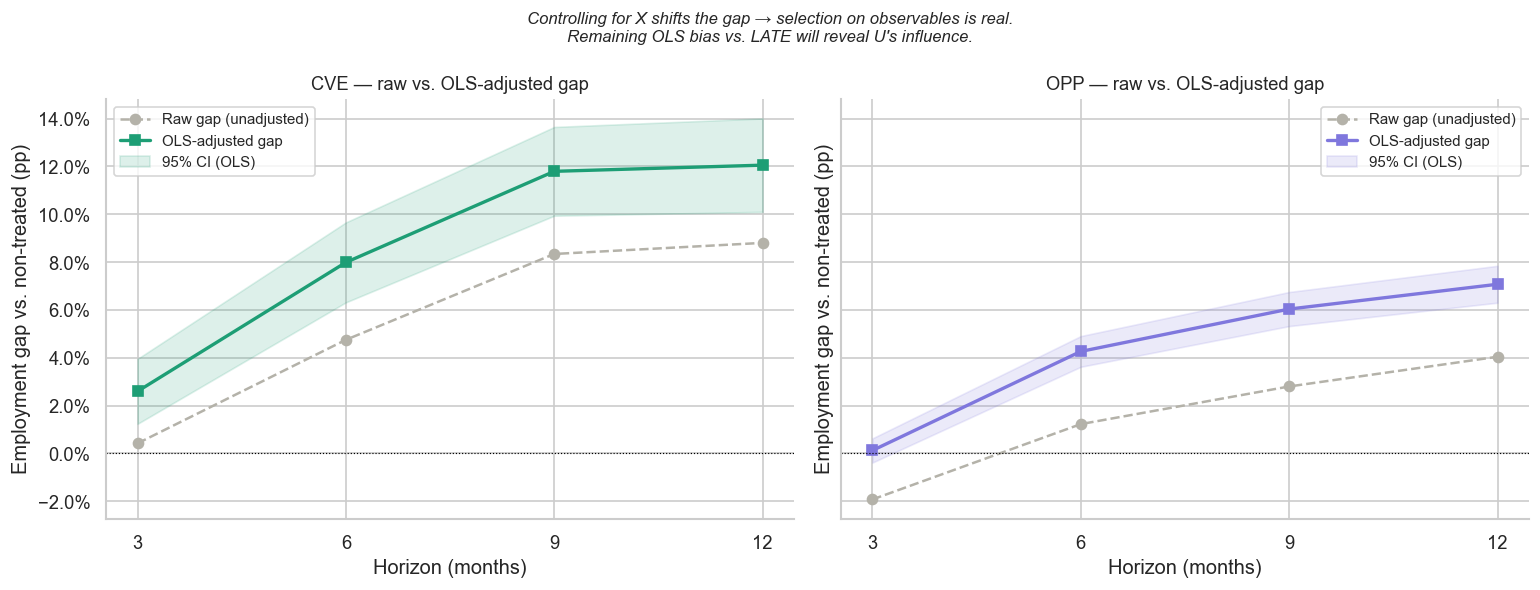

In [22]:
# ── Visual: raw vs OLS gap across horizons ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, prog, raw_col, ols_col, se_col in [
    (axes[0], "CVE", "raw_CVE", "ols_CVE", "ols_se_CVE"),
    (axes[1], "OPP", "raw_OPP", "ols_OPP", "ols_se_OPP"),
]:
    ax.plot(gap_df["months"], gap_df[raw_col] * 100,
            marker="o", linestyle="--", color="#B4B2A9",
            label="Raw gap (unadjusted)", linewidth=1.5)
    ax.plot(gap_df["months"], gap_df[ols_col] * 100,
            marker="s", linestyle="-", color=COLORS[prog],
            label="OLS-adjusted gap", linewidth=2)
    ax.fill_between(
        gap_df["months"],
        (gap_df[ols_col] - 1.96 * gap_df[se_col]) * 100,
        (gap_df[ols_col] + 1.96 * gap_df[se_col]) * 100,
        alpha=0.15, color=COLORS[prog], label="95% CI (OLS)"
    )
    ax.axhline(0, color="black", linewidth=0.7, linestyle=":")
    ax.set_title(f"{prog} — raw vs. OLS-adjusted gap", fontsize=11)
    ax.set_xlabel("Horizon (months)")
    ax.set_ylabel("Employment gap vs. non-treated (pp)")
    ax.set_xticks([3, 6, 9, 12])
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.legend(fontsize=9)

fig.suptitle("Controlling for X shifts the gap → selection on observables is real.\n"
             "Remaining OLS bias vs. LATE will reveal U's influence.",
             fontsize=10, style="italic")
plt.tight_layout()
plt.show()

**Takeaway — U → D, U → Y confirmed.** Controlling for X already shifts the estimated gap, confirming selection on observables. But OLS ignorability is untestable: unobservable factors (motivation, network, health) are likely to drive both take-up and outcomes. The further wedge between OLS and LATE estimates (shown in the DML notebook) will quantify U's influence and justify the IV strategy.

---
## Part 5 — Outcome Distributions: D → Y

Before estimating causal effects, we document raw employment trajectories and distributions. This motivates the central question: how much of the observed gap is causal?

> **Justifies arrows:** `D_CVE → Y`, `D_OPP → Y`.

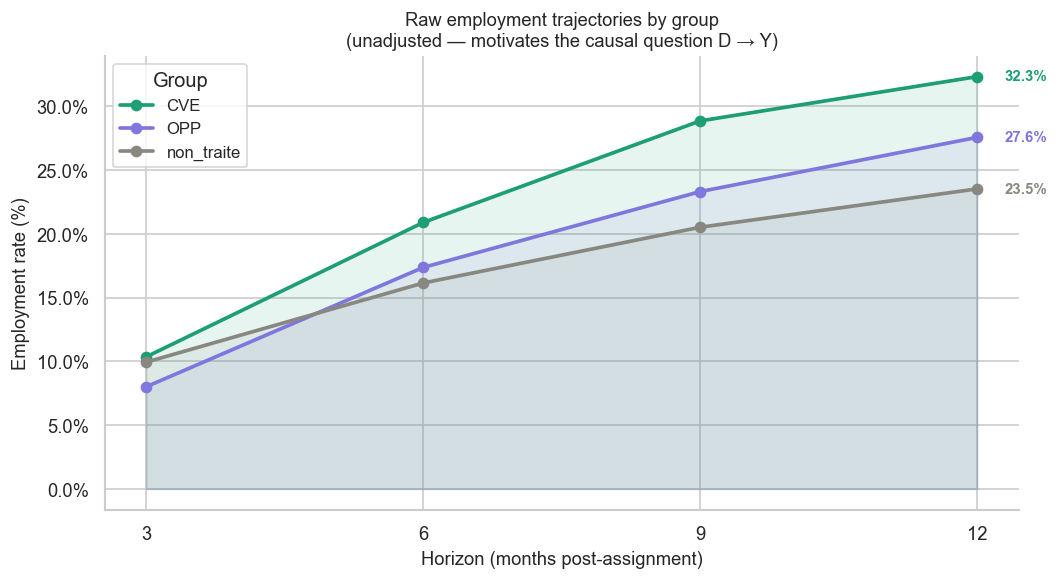

In [23]:
# ── 5a. Employment trajectory (line + fill) ───────────────────────
traj = (
    df_eda.groupby("group")[horizons].mean().T
    .rename(index=dict(zip(horizons, months))) * 100
)

fig, ax = plt.subplots(figsize=(9, 5))
for group in ["CVE", "OPP", "non_traite"]:
    if group not in traj.columns: continue
    ax.fill_between(traj.index, traj[group], alpha=0.10, color=COLORS[group])
    ax.plot(traj.index, traj[group], marker="o", linewidth=2.2,
            color=COLORS[group], label=group)
    ax.annotate(f"{traj[group].iloc[-1]:.1f}%",
                xy=(12, traj[group].iloc[-1]),
                xytext=(12.3, traj[group].iloc[-1]),
                va="center", fontsize=9, color=COLORS[group], fontweight="bold")

ax.set_xlabel("Horizon (months post-assignment)", fontsize=11)
ax.set_ylabel("Employment rate (%)", fontsize=11)
ax.set_title("Raw employment trajectories by group\n(unadjusted — motivates the causal question D → Y)", fontsize=11)
ax.set_xticks([3, 6, 9, 12])
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(title="Group", fontsize=10)
plt.tight_layout()
plt.show()

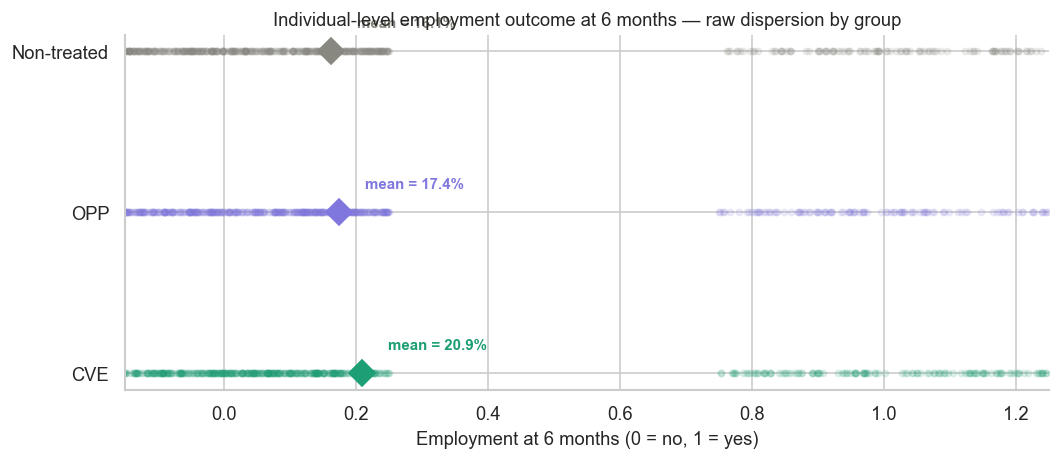

In [24]:
# ── 5b. Jitter + mean dot at 6 months ────────────────────────────
df_plot = df_eda[["group", "EMPLOI_6MOIS"]].dropna().copy()
df_plot["EMPLOI_6MOIS"] = pd.to_numeric(df_plot["EMPLOI_6MOIS"], errors="coerce").dropna()
df_plot = df_plot.dropna()

group_order  = ["CVE", "OPP", "non_traite"]
group_labels = {"CVE": "CVE", "OPP": "OPP", "non_traite": "Non-treated"}

fig, ax = plt.subplots(figsize=(9, 4))
rng = np.random.default_rng(42)

for i, group in enumerate(group_order):
    sub = df_plot.loc[df_plot["group"] == group, "EMPLOI_6MOIS"]
    if len(sub) == 0: continue
    sample = sub.sample(min(len(sub), 600), random_state=42)
    jitter = rng.uniform(-0.25, 0.25, size=len(sample))
    ax.scatter(sample.values + jitter, [i] * len(sample),
               alpha=0.12, color=COLORS[group], s=14)
    ax.plot([sub.mean()], [i], marker="D", markersize=11,
            color=COLORS[group], zorder=5)
    ax.annotate(f"mean = {sub.mean():.1%}",
                xy=(sub.mean(), i), xytext=(sub.mean() + 0.04, i + 0.15),
                fontsize=9, color=COLORS[group], fontweight="bold")

ax.set_yticks(range(len(group_order)))
ax.set_yticklabels([group_labels[g] for g in group_order], fontsize=11)
ax.set_xlabel("Employment at 6 months (0 = no, 1 = yes)", fontsize=11)
ax.set_title("Individual-level employment outcome at 6 months — raw dispersion by group", fontsize=11)
ax.set_xlim(-0.15, 1.25)
plt.tight_layout()
plt.show()

**Takeaway — D → Y motivated.** CVE participants consistently outperform OPP participants and non-treated individuals across all horizons. The gap opens early (3 months) and persists through 12 months. However, since groups differ on observables (Part 1) and unobservables (Part 4), we cannot attribute this gap causally without IV/DML identification.

---
## Causal Mapping: DAG

We now formalise all structural assumptions as a Directed Acyclic Graph. Every edge is backed by at least one empirical result above.

| Arrow | Empirical basis |
|---|---|
| `Z → D` | Part 2 — compliance tables show Z strongly predicts D |
| `Z ✗→ Y` | Part 2 — exclusion restriction holds by randomisation design |
| `X → D, X → Y` | Part 1 — t-tests, SMD, omnibus F-test |
| `rsqstat → D, rsqstat → Y` | Part 3 — composition tables and t-test |
| `U → D, U → Y` | Part 4 — raw vs. OLS gap; further confirmed by OLS vs. LATE wedge in DML notebook |
| `D → Y` | Part 5 — employment trajectories motivate the causal question |

── CVE ──
  Exclusion restriction — Z_CVE ⊥ Y:      False
  Instrument independence — Z_CVE ⊥ U:    True
  Relevance — Z_CVE correlated with D_CVE:  True

── OPP ──
  Exclusion restriction — Z_OPP ⊥ Y:      False
  Instrument independence — Z_OPP ⊥ U:    True
  Relevance — Z_OPP correlated with D_OPP:  True



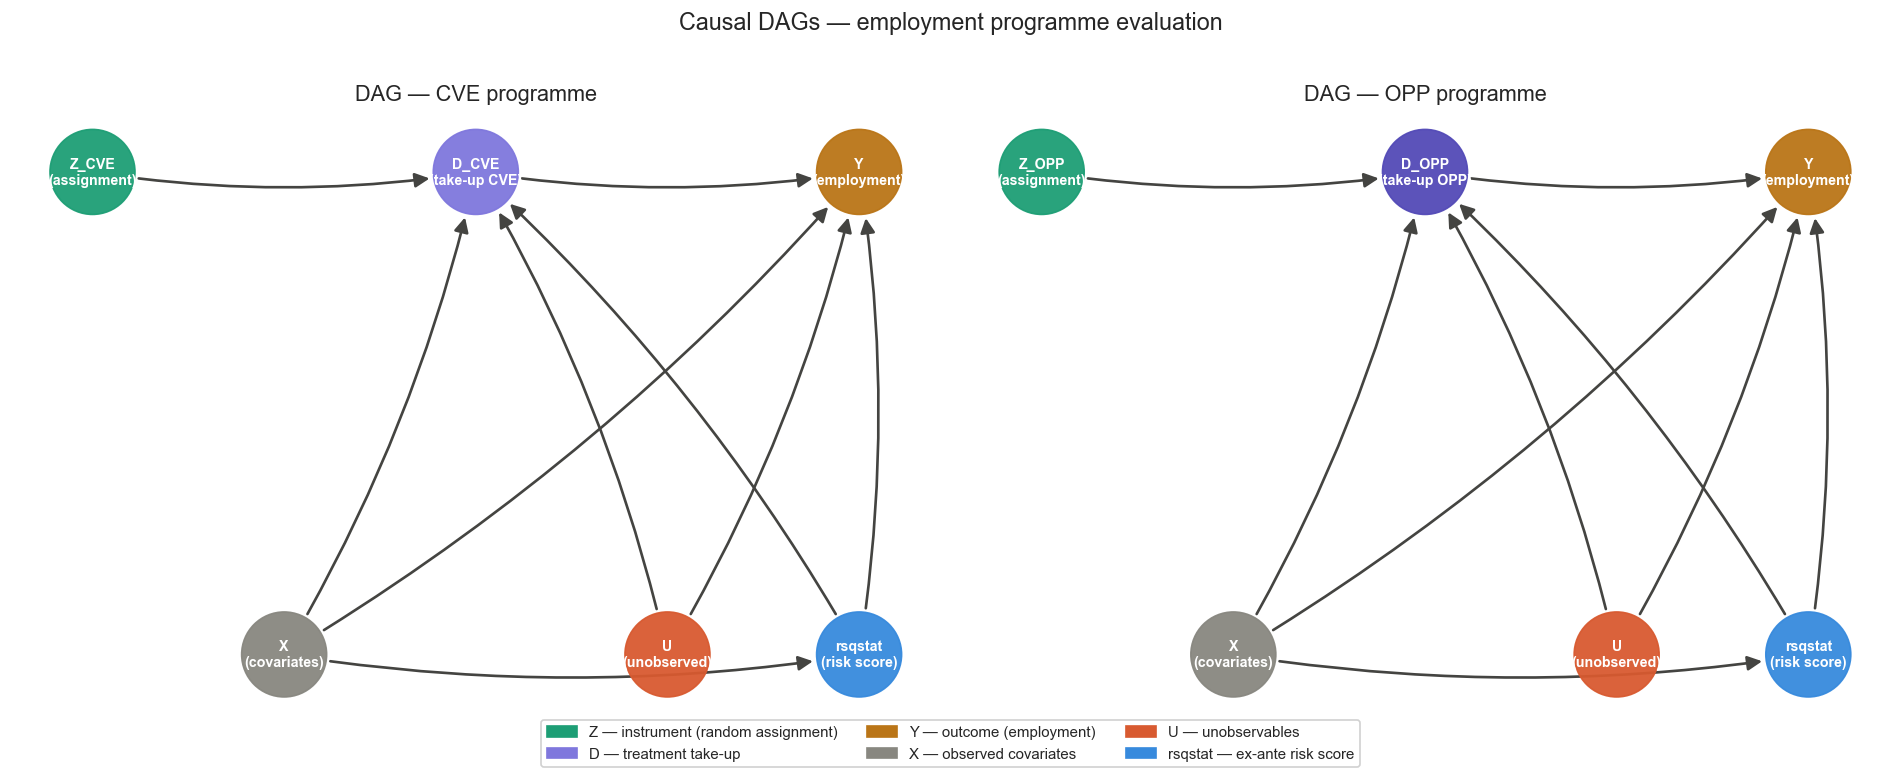

In [35]:
import collections, collections.abc
collections.Iterable = collections.abc.Iterable
from causalgraphicalmodels import CausalGraphicalModel
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Définir les deux DAGs ─────────────────────────────────────────
dag_cve = CausalGraphicalModel(
    nodes=["Z_CVE", "D_CVE", "Y", "X", "U", "rsqstat"],
    edges=[
        ("Z_CVE", "D_CVE"),
        ("D_CVE", "Y"),
        ("X", "D_CVE"), ("X", "Y"), ("X", "rsqstat"),
        ("rsqstat", "D_CVE"), ("rsqstat", "Y"),
        ("U", "D_CVE"), ("U", "Y"),
    ]
)

dag_opp = CausalGraphicalModel(
    nodes=["Z_OPP", "D_OPP", "Y", "X", "U", "rsqstat"],
    edges=[
        ("Z_OPP", "D_OPP"),
        ("D_OPP", "Y"),
        ("X", "D_OPP"), ("X", "Y"), ("X", "rsqstat"),
        ("rsqstat", "D_OPP"), ("rsqstat", "Y"),
        ("U", "D_OPP"), ("U", "Y"),
    ]
)

# ── Vérification des hypothèses ───────────────────────────────────
for name, dag, z, d in [
    ("CVE", dag_cve, "Z_CVE", "D_CVE"),
    ("OPP", dag_opp, "Z_OPP", "D_OPP"),
]:
    print(f"── {name} ──")
    print(f"  Exclusion restriction — {z} ⊥ Y:     ",
          dag.is_d_separated(z, "Y", set()))
    print(f"  Instrument independence — {z} ⊥ U:   ",
          dag.is_d_separated(z, "U", set()))
    print(f"  Relevance — {z} correlated with {d}: ",
          not dag.is_d_separated(z, d, set()))
    print()

# ── Visualisation networkx côte à côte ───────────────────────────
COLORS = {
    "Z_CVE":    "#1D9E75",
    "Z_OPP":    "#1D9E75",
    "D_CVE":    "#7F77DD",
    "D_OPP":    "#534AB7",
    "Y":        "#BA7517",
    "X":        "#888780",
    "U":        "#D85A30",
    "rsqstat":  "#378ADD",
}

LABELS = {
    "Z_CVE":   "Z_CVE\n(assignment)",
    "Z_OPP":   "Z_OPP\n(assignment)",
    "D_CVE":   "D_CVE\n(take-up CVE)",
    "D_OPP":   "D_OPP\n(take-up OPP)",
    "Y":       "Y\n(employment)",
    "X":       "X\n(covariates)",
    "U":       "U\n(unobserved)",
    "rsqstat": "rsqstat\n(risk score)",
}

# Même layout pour les deux graphes (symétrique)
pos_cve = {
    "Z_CVE":   (0,   2),
    "X":       (1,   0),
    "U":       (3,   0),
    "rsqstat": (4,   0),
    "D_CVE":   (2,   2),
    "Y":       (4,   2),
}
pos_opp = {
    "Z_OPP":   (0,   2),
    "X":       (1,   0),
    "U":       (3,   0),
    "rsqstat": (4,   0),
    "D_OPP":   (2,   2),
    "Y":       (4,   2),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, dag, pos, title in [
    (axes[0], dag_cve, pos_cve, "DAG — CVE programme"),
    (axes[1], dag_opp, pos_opp, "DAG — OPP programme"),
]:
    G = dag.dag
    node_colors = [COLORS[n] for n in G.nodes()]
    labels      = {n: LABELS[n] for n in G.nodes()}

    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_color=node_colors,
                           node_size=2600, alpha=0.95)
    nx.draw_networkx_edges(G, pos, ax=ax,
                           edge_color="#444441",
                           arrows=True, arrowsize=18,
                           width=1.6,
                           connectionstyle="arc3,rad=0.08",
                           min_source_margin=28,
                           min_target_margin=28)
    nx.draw_networkx_labels(G, pos, labels=labels, ax=ax,
                            font_color="white", font_size=8.5,
                            font_weight="bold")
    ax.set_title(title, fontsize=13, pad=12)
    ax.axis("off")

# Légende commune
legend_items = [
    mpatches.Patch(color="#1D9E75", label="Z — instrument (random assignment)"),
    mpatches.Patch(color="#7F77DD", label="D — treatment take-up"),
    mpatches.Patch(color="#BA7517", label="Y — outcome (employment)"),
    mpatches.Patch(color="#888780", label="X — observed covariates"),
    mpatches.Patch(color="#D85A30", label="U — unobservables"),
    mpatches.Patch(color="#378ADD", label="rsqstat — ex-ante risk score"),
]
fig.legend(handles=legend_items, loc="lower center", ncol=3,
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.05))

plt.suptitle("Causal DAGs — employment programme evaluation",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()